In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

In [2]:
list_names_files = glob.glob("../data/riesgo_academico/all_*")
df_materias = pd.read_csv("../data/riesgo_academico/dificultad_materia.csv")
df_materias_xslx = pd.read_excel('../data/riesgo_academico/saved/TODOESPOL.xlsx')
df_estudiantes_novatos = pd.read_csv('../data/riesgo_academico/saved/estudiantes_novatos_disponibles.csv')
df_2026_1S = pd.read_csv('../data/riesgo_academico/all_2026_1S.csv')

In [3]:
df_estudiantes_novatos.rename(columns={"ESTUDIANTES": "estudiantes_novatos"}, inplace=True)
df_estudiantes_novatos["COD_MATERIA_ACAD"] = df_estudiantes_novatos["COD_MATERIA_ACAD"].astype(str).str.strip()
df_2026_1S["COD_MATERIA_ACAD_MO"] = (
    df_2026_1S["COD_MATERIA_ACAD_MO"].astype(str).str.strip()
)

In [4]:
df_materias_xslx["CodigoMateria"].nunique()

726

In [5]:
df_complete = pd.DataFrame()

for file in list_names_files:
    if not "2026" in file:
        print("file", file)
        split_file = file.split("_")
        termino = split_file[-1].split(".")[0]
        if termino == "3S":
            continue
        
        df = pd.read_csv(file)

        df["anio"] = split_file[-2]
        df["termino"] = termino
        if not("MATERIA" in df.keys()):
            df = pd.merge(df, df_materias[["CODIGOMATERIA", "MATERIA"]], left_on="COD_MATERIA_ACAD_MO", right_on="CODIGOMATERIA")

        df_complete = pd.concat([df_complete, df], ignore_index=True)

file ../data/riesgo_academico\all_2020_1S.csv
file ../data/riesgo_academico\all_2020_2S.csv
file ../data/riesgo_academico\all_2021_1S.csv
file ../data/riesgo_academico\all_2021_2S.csv
file ../data/riesgo_academico\all_2022_1S.csv
file ../data/riesgo_academico\all_2022_2S.csv
file ../data/riesgo_academico\all_2023_1S.csv
file ../data/riesgo_academico\all_2023_2S.csv
file ../data/riesgo_academico\all_2024_1S.csv
file ../data/riesgo_academico\all_2024_2S.csv
file ../data/riesgo_academico\all_2025_1S.csv
file ../data/riesgo_academico\all_2025_2S.csv


In [6]:
df_complete

,COD_ESTUDIANTE,COD_MATERIA_ACAD_MO,ESTADO_MAT_TOMADA_MO,VEZ_TOMADA_MO,NOTA1_MO,NOTA2MO,PROMEDIO_MO,DIFICULTAD_MO,T_MAT_TOMADAS,PROM_1PARCIAL,...,FACIL,MODERADA,DIFICIL,MUY_DIFICIL,promedio_general,CODIGOMATERIA,MATERIA,anio,termino,PROMEDIO_GENERAL
0,201160178,ACUG1035,AP,1,87,93,"9,00","7,90",53.0,59.0,...,0,2,1,0,NaN,ACUG1035,ACUICULTURA ORNAMENTAL,2020,1S,NaN
1,201310353,ACUG1035,AP,1,85,89,"8,70","7,90",59.0,61.0,...,0,2,1,0,NaN,ACUG1035,ACUICULTURA ORNAMENTAL,2020,1S,NaN
2,201313869,ACUG1035,AP,1,86,89,"8,75","7,90",59.0,56.0,...,1,1,0,1,NaN,ACUG1035,ACUICULTURA ORNAMENTAL,2020,1S,NaN
3,201507649,ACUG1035,AP,1,83,93,"8,80","7,90",49.0,65.0,...,0,2,2,0,NaN,ACUG1035,ACUICULTURA ORNAMENTAL,2020,1S,NaN
4,201607884,ACUG1035,AP,1,95,95,"9,50","7,90",39.0,72.0,...,1,1,1,0,NaN,ACUG1035,ACUICULTURA ORNAMENTAL,2020,1S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366895,202300422,TURG2037,AC,1,0,0,"0,00","7,22",27.0,73.0,...,1,0,1,3,NaN,TURG2037,OPERACIÓN TURÍSTICA,2025,2S,"7,92"
366896,202104683,TURG2037,AC,1,0,0,"0,00","7,22",37.0,65.0,...,0,0,1,2,NaN,TURG2037,OPERACIÓN TURÍSTICA,2025,2S,"7,54"
366897,202111548,TURG2037,AC,1,0,0,"0,00","7,22",36.0,66.0,...,0,0,1,3,NaN,TURG2037,OPERACIÓN TURÍSTICA,2025,2S,"7,53"
366898,202103719,TURG2037,AC,1,0,0,"0,00","7,22",33.0,67.0,...,0,0,1,2,NaN,TURG2037,OPERACIÓN TURÍSTICA,2025,2S,"7,25"


In [7]:
df_complete["COD_MATERIA_ACAD_MO"].nunique()

707

In [8]:
df_complete["COD_ESTUDIANTE"] = df_complete["COD_ESTUDIANTE"].astype(str)

In [9]:
df_complete.shape

(366900, 30)

In [10]:
df_complete.groupby(["anio", "termino"]).size() 

anio  termino
2020  1S         35871
      2S         34086
2021  1S         32727
      2S         31286
2022  1S         29507
      2S         28859
2023  1S         28301
      2S         28195
2024  1S         28707
      2S         28488
2025  1S         30264
      2S         30609
dtype: int64

In [11]:
df_complete["periodo"] = df_complete["anio"].astype(str) + "_" + df_complete["termino"].astype(str)
df_complete.groupby(["periodo"]).size() 

periodo
2020_1S    35871
2020_2S    34086
2021_1S    32727
2021_2S    31286
2022_1S    29507
2022_2S    28859
2023_1S    28301
2023_2S    28195
2024_1S    28707
2024_2S    28488
2025_1S    30264
2025_2S    30609
dtype: int64

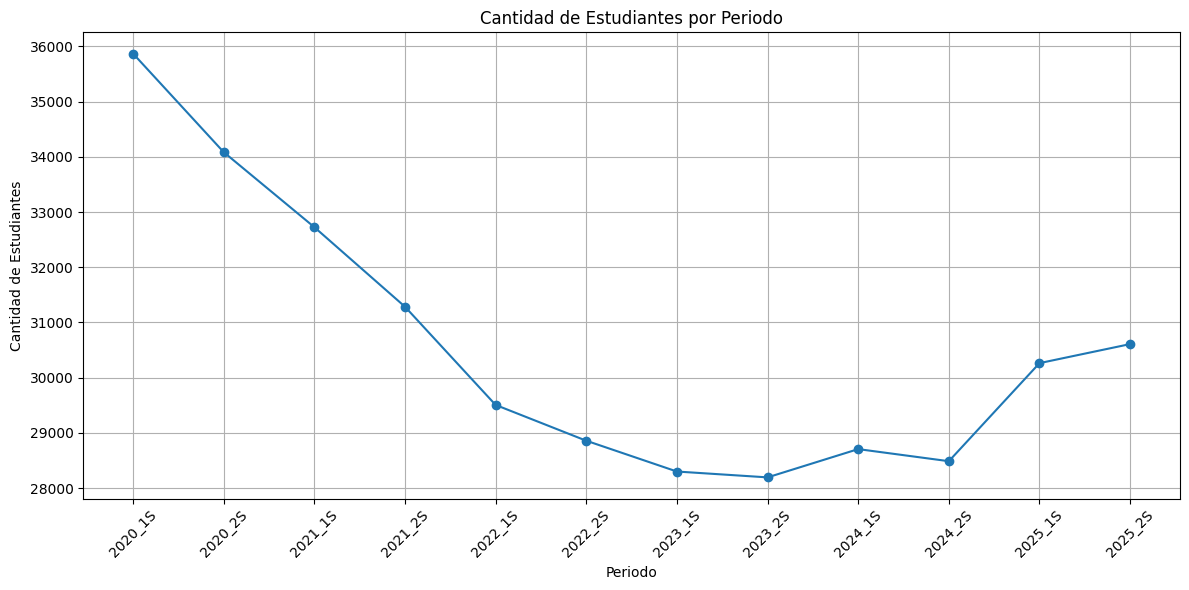

In [12]:
# grafico de serie de tiempo de cantidad de estudiantes por periodo
df_periodo = df_complete.groupby("periodo").size().reset_index(name="cantidad_estudiantes")
plt.figure(figsize=(12, 6))
plt.plot(df_periodo["periodo"], df_periodo["cantidad_estudiantes"], marker='o')
plt.xticks(rotation=45)
plt.title("Cantidad de Estudiantes por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Cantidad de Estudiantes")
plt.grid()
plt.tight_layout()
plt.show()


In [13]:
# dataframe de filas por materias y codigo de materia, columnas de cantidad de sus estudiantes por periodo
df_materia_periodo = df_complete.groupby(["COD_MATERIA_ACAD_MO", "periodo"]).size().unstack(fill_value=0)
df_materia_periodo

periodo,2020_1S,2020_2S,2021_1S,2021_2S,2022_1S,2022_2S,2023_1S,2023_2S,2024_1S,2024_2S,2025_1S,2025_2S
COD_MATERIA_ACAD_MO,,,,,,,,,,,,
ACUG1035,15,11,24,8,14,10,8,1,6,2,5,8
ACUG1036,22,12,14,10,3,4,3,5,5,5,8,12
ACUG1039,5,7,13,10,13,10,5,3,7,3,4,2
ACUG1040,5,14,6,11,4,6,3,9,2,5,3,2
ACUG1041,2,0,9,1,6,9,0,13,4,13,17,1
...,...,...,...,...,...,...,...,...,...,...,...,...
TURG2033,23,16,20,17,37,33,39,28,35,22,32,41
TURG2034,65,51,78,37,22,35,34,37,20,30,41,24
TURG2035,37,104,51,39,36,44,34,29,36,58,46,37


In [14]:
# MATERIA el nombre esta mal
# # dataframe de filas por materias y codigo de materia, columnas de cantidad de sus estudiantes por periodo
# # agrupar por codigo de materia, nombre de materia y periodo, y contar la cantidad de estudiantes
# df_materia_periodo = df_complete.groupby(["COD_MATERIA_ACAD_MO", "MATERIA", "periodo"]).size().reset_index(name="cantidad_estudiantes")
# # pivotear el dataframe para tener las columnas de cada periodo (la columna periodo) y los valores de cantidad de estudiantes, rellenando con 0 los valores faltantes
# df_materia_periodo_pivot = df_materia_periodo.pivot_table(index=["COD_MATERIA_ACAD_MO", "MATERIA"], columns="periodo", values="cantidad_estudiantes", fill_value=0).reset_index()
# df_materia_periodo_pivot

In [15]:
# df_materias_xslx[["NombreMateria", "CodigoMateria"]]
df_materia_periodo_nom_mo = pd.merge(df_materias_xslx[["NombreMateria", "CodigoMateria"]], df_materia_periodo.reset_index(), left_on="CodigoMateria", right_on="COD_MATERIA_ACAD_MO")

In [16]:
df_materias_xslx["CodigoMateria"].nunique() - df_materia_periodo_nom_mo["COD_MATERIA_ACAD_MO"].nunique()

45

In [17]:
# df_materia_periodo_nom_mo[df_materia_periodo_nom_mo["2026_1S"] == 0].shape[0]
"Cantidad faltante en el estimado del 2026", df_materia_periodo_nom_mo[~df_materia_periodo_nom_mo["CodigoMateria"].isin(df_2026_1S["COD_MATERIA_ACAD_MO"].unique())]["CodigoMateria"].nunique()

('Cantidad faltante en el estimado del 2026', 41)

In [18]:
df_materia_periodo_nom_mo

,NombreMateria,CodigoMateria,COD_MATERIA_ACAD_MO,2020_1S,2020_2S,2021_1S,2021_2S,2022_1S,2022_2S,2023_1S,2023_2S,2024_1S,2024_2S,2025_1S,2025_2S
0,ACUICULTURA ORNAMENTAL,ACUG1035,ACUG1035,15,11,24,8,14,10,8,1,6,2,5,8
1,ANÁLISIS DE DATOS ACUÍCOLAS,ACUG1036,ACUG1036,22,12,14,10,3,4,3,5,5,5,8,12
2,CULTIVO DE ESPECIES NO TRADICIONALES,ACUG1039,ACUG1039,5,7,13,10,13,10,5,3,7,3,4,2
3,CULTIVO DE PLANCTON,ACUG1040,ACUG1040,5,14,6,11,4,6,3,9,2,5,3,2
4,ECOSISTEMAS ACUÍCOLAS,ACUG1041,ACUG1041,2,0,9,1,6,9,0,13,4,13,17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,PLANIFICACIÓN DE ESPACIOS TURÍSTICOS,TURG2033,TURG2033,23,16,20,17,37,33,39,28,35,22,32,41
677,PATRIMONIO NATURAL Y CULTURAL,TURG2034,TURG2034,65,51,78,37,22,35,34,37,20,30,41,24
678,GEOGRAFÍA TURÍSTICA,TURG2035,TURG2035,37,104,51,39,36,44,34,29,36,58,46,37
679,TEORÍA DEL TURISMO,TURG2036,TURG2036,0,86,35,32,35,37,28,27,35,51,32,36


In [19]:
# # eliminar 2026_1S (ya se descarta de las lecturas de los csv)
# df_materia_periodo_nom_mo_cp = df_materia_periodo_nom_mo.drop(columns=["2026_1S"])
df_materia_periodo_nom_mo_cp = df_materia_periodo_nom_mo.copy()

In [20]:
df_materia_periodo_nom_mo_cp

,NombreMateria,CodigoMateria,COD_MATERIA_ACAD_MO,2020_1S,2020_2S,2021_1S,2021_2S,2022_1S,2022_2S,2023_1S,2023_2S,2024_1S,2024_2S,2025_1S,2025_2S
0,ACUICULTURA ORNAMENTAL,ACUG1035,ACUG1035,15,11,24,8,14,10,8,1,6,2,5,8
1,ANÁLISIS DE DATOS ACUÍCOLAS,ACUG1036,ACUG1036,22,12,14,10,3,4,3,5,5,5,8,12
2,CULTIVO DE ESPECIES NO TRADICIONALES,ACUG1039,ACUG1039,5,7,13,10,13,10,5,3,7,3,4,2
3,CULTIVO DE PLANCTON,ACUG1040,ACUG1040,5,14,6,11,4,6,3,9,2,5,3,2
4,ECOSISTEMAS ACUÍCOLAS,ACUG1041,ACUG1041,2,0,9,1,6,9,0,13,4,13,17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,PLANIFICACIÓN DE ESPACIOS TURÍSTICOS,TURG2033,TURG2033,23,16,20,17,37,33,39,28,35,22,32,41
677,PATRIMONIO NATURAL Y CULTURAL,TURG2034,TURG2034,65,51,78,37,22,35,34,37,20,30,41,24
678,GEOGRAFÍA TURÍSTICA,TURG2035,TURG2035,37,104,51,39,36,44,34,29,36,58,46,37
679,TEORÍA DEL TURISMO,TURG2036,TURG2036,0,86,35,32,35,37,28,27,35,51,32,36


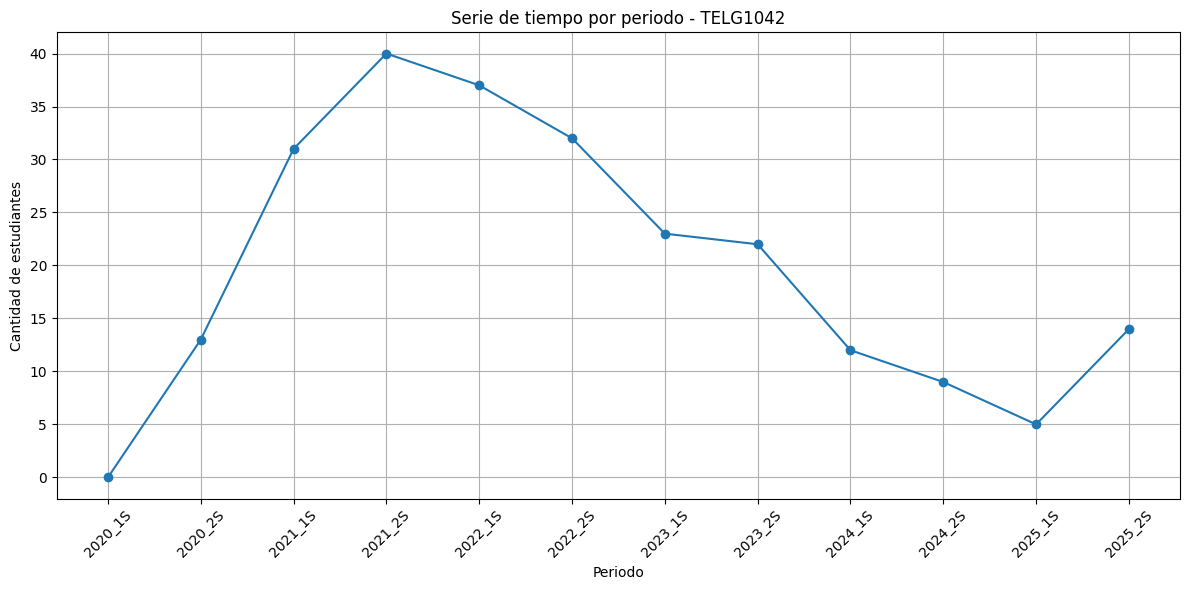

In [21]:
# gafica por de tiempo de df_materia_periodo_nom_mo_cp por periodo a partir de codigo en COD_MATERIA_ACAD_MO
codigo_materia = "TELG1042"
tmp_df = df_materia_periodo_nom_mo_cp[df_materia_periodo_nom_mo_cp["COD_MATERIA_ACAD_MO"] == codigo_materia]

# columnas que representan periodos (ej: 2024_1S, 2025_2S)
period_cols = [c for c in tmp_df.columns if isinstance(c, str) and "_" in c and c.endswith("S")]

# ordenar periodos por año y término
period_cols = sorted(period_cols, key=lambda x: (int(x.split("_")[0]), int(x.split("_")[1].replace("S", ""))))

# valores de la única fila de la materia
serie = tmp_df.iloc[0][period_cols].astype(float)

plt.figure(figsize=(12, 6))
plt.plot(period_cols, serie.values, marker="o")
plt.xticks(rotation=45)
plt.title(f"Serie de tiempo por periodo - {codigo_materia}")
plt.xlabel("Periodo")
plt.ylabel("Cantidad de estudiantes")
plt.grid(True)
plt.tight_layout()
plt.show()


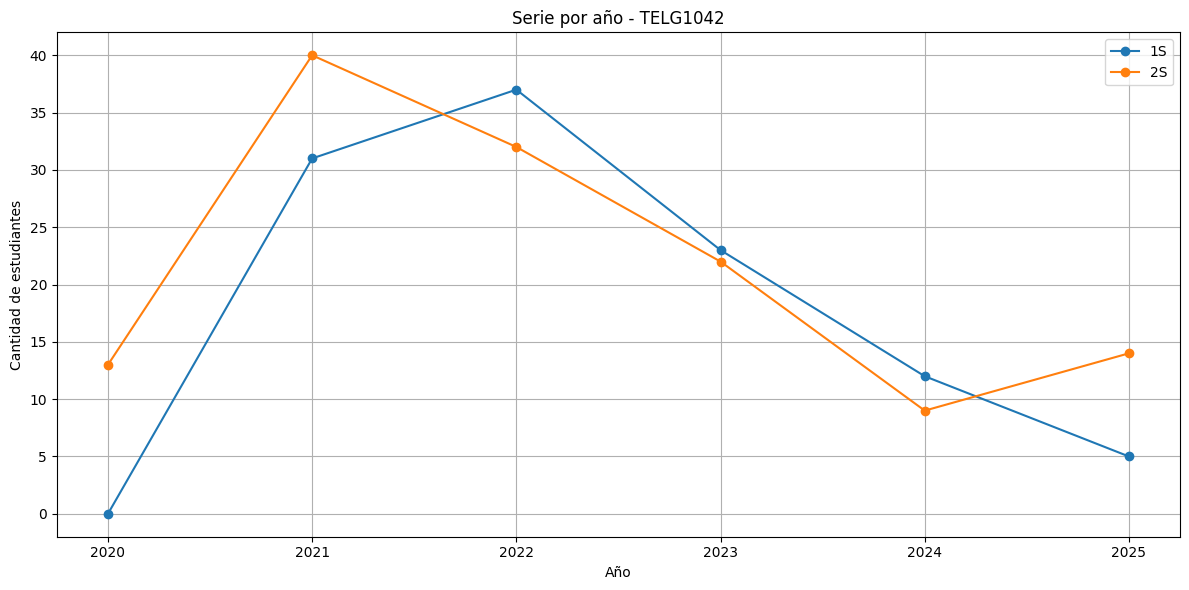

In [22]:
row = tmp_df.iloc[0]

# columnas tipo 2020_1S, 2020_2S, ...
period_cols_1S = [c for c in tmp_df.columns if isinstance(c, str) and "_" in c and c.endswith("1S")]
period_cols_2S = [c for c in tmp_df.columns if isinstance(c, str) and "_" in c and c.endswith("2S")]

# años disponibles en cualquiera de las dos series
years_1S = {int(c.split("_")[0]) for c in period_cols_1S}
years_2S = {int(c.split("_")[0]) for c in period_cols_2S}
years = sorted(years_1S.union(years_2S))

# valores por año (NaN si no existe esa columna para ese año)
y_1S = [float(row[f"{y}_1S"]) if f"{y}_1S" in tmp_df.columns else float("nan") for y in years]
y_2S = [float(row[f"{y}_2S"]) if f"{y}_2S" in tmp_df.columns else float("nan") for y in years]

plt.figure(figsize=(12, 6))
plt.plot(years, y_1S, marker="o", label="1S")
plt.plot(years, y_2S, marker="o", label="2S")
plt.xticks(years)
plt.title(f"Serie por año - {codigo_materia}")
plt.xlabel("Año")
plt.ylabel("Cantidad de estudiantes")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def proyectar_materia(df_pivot, codigo_materia, anios_proyectar=[2026]):
    """
    Proyecta los valores de 1S y 2S para los años indicados usando regresión lineal.
    Retorna dict con claves tipo '2026_1S', '2026_2S'.
    """
    row = df_pivot[df_pivot["COD_MATERIA_ACAD_MO"] == codigo_materia]
    if row.empty:
        return {}
    row = row.iloc[0]

    period_cols_1S = sorted([c for c in df_pivot.columns if isinstance(c, str) and c.endswith("1S") and "_" in c],
                             key=lambda x: int(x.split("_")[0]))
    period_cols_2S = sorted([c for c in df_pivot.columns if isinstance(c, str) and c.endswith("2S") and "_" in c],
                             key=lambda x: int(x.split("_")[0]))

    proyecciones = {}

    for sufijo, cols in [("1S", period_cols_1S), ("2S", period_cols_2S)]:
        years_hist = np.array([int(c.split("_")[0]) for c in cols])
        values_hist = np.array([float(row[c]) for c in cols])

        # filtrar ceros (periodos sin datos) para no distorsionar la tendencia
        mask = values_hist > 0
        if mask.sum() < 2:
            for y in anios_proyectar:
                proyecciones[f"{y}_{sufijo}"] = np.nan
            continue

        coef = np.polyfit(years_hist[mask], values_hist[mask], deg=1)
        poly = np.poly1d(coef)

        for y in anios_proyectar:
            pred = max(0, round(poly(y)))
            proyecciones[f"{y}_{sufijo}"] = pred

    return proyecciones

In [24]:
def proyectar_materia_pro(df_pivot, codigo_materia, anios_proyectar=[2026], metodo='regresion', ventana=3):
    """
    Proyecta valores usando 'regresion' lineal o 'media_movil'.
    'ventana' es el número de periodos recientes para la media móvil.
    """
    row = df_pivot[df_pivot["COD_MATERIA_ACAD_MO"] == codigo_materia]
    if row.empty:
        return {}
    row = row.iloc[0]

    # Extraer columnas de semestres (1S y 2S)
    period_cols_1S = sorted([c for c in df_pivot.columns if str(c).endswith("1S")], key=lambda x: int(x.split("_")[0]))
    period_cols_2S = sorted([c for c in df_pivot.columns if str(c).endswith("2S")], key=lambda x: int(x.split("_")[0]))

    proyecciones = {}

    for sufijo, cols in [("1S", period_cols_1S), ("2S", period_cols_2S)]:
        years_hist = np.array([int(c.split("_")[0]) for c in cols])
        values_hist = np.array([float(row[c]) for c in cols])

        # Limpieza de ceros
        mask = values_hist > 0
        v_validos = values_hist[mask]
        y_validos = years_hist[mask]

        if len(v_validos) < 2:
            for y in anios_proyectar:
                proyecciones[f"{y}_{sufijo}"] = np.nan
            continue

        if metodo == 'regresion':
            # Lógica original: proyecta hacia el futuro
            coef = np.polyfit(y_validos, v_validos, deg=1)
            poly = np.poly1d(coef)
            for y in anios_proyectar:
                proyecciones[f"{y}_{sufijo}"] = max(0, round(poly(y)))

        elif metodo == 'media_movil':
            # Lógica de promedio: toma los últimos N valores con datos
            promedio = v_validos[-ventana:].mean()
            for y in anios_proyectar:
                proyecciones[f"{y}_{sufijo}"] = round(promedio)

    return proyecciones

In [25]:
def graph_serie(codigo_materia, proyecciones):
    period_cols_1S = sorted([c for c in df_materia_periodo_nom_mo_cp.columns if isinstance(c, str) and c.endswith("1S") and "_" in c],
                         key=lambda x: int(x.split("_")[0]))
    period_cols_2S = sorted([c for c in df_materia_periodo_nom_mo_cp.columns if isinstance(c, str) and c.endswith("2S") and "_" in c],
                            key=lambda x: int(x.split("_")[0]))

    row = df_materia_periodo_nom_mo_cp[df_materia_periodo_nom_mo_cp["COD_MATERIA_ACAD_MO"] == codigo_materia].iloc[0]

    years_hist = sorted({int(c.split("_")[0]) for c in period_cols_1S + period_cols_2S})
    y_1S = [float(row[f"{y}_1S"]) if f"{y}_1S" in df_materia_periodo_nom_mo_cp.columns else np.nan for y in years_hist]
    y_2S = [float(row[f"{y}_2S"]) if f"{y}_2S" in df_materia_periodo_nom_mo_cp.columns else np.nan for y in years_hist]

    # agregar año proyectado
    years_ext = years_hist + [2026]
    y_1S_ext = y_1S + [proyecciones.get("2026_1S", np.nan)]
    y_2S_ext = y_2S + [proyecciones.get("2026_2S", np.nan)]

    plt.figure(figsize=(13, 6))
    plt.plot(years_hist, y_1S, marker="o", label="1S histórico", color="steelblue")
    plt.plot(years_hist, y_2S, marker="o", label="2S histórico", color="darkorange")

    # puntos proyectados
    plt.plot([2026], [proyecciones.get("2026_1S", np.nan)], marker="*", markersize=14,
            color="steelblue", linestyle="--", label=f"1S proyectado 2026 = {proyecciones.get('2026_1S', 'N/A')}")
    plt.plot([2026], [proyecciones.get("2026_2S", np.nan)], marker="*", markersize=14,
            color="darkorange", linestyle="--", label=f"2S proyectado 2026 = {proyecciones.get('2026_2S', 'N/A')}")

    # líneas punteadas de tendencia hasta 2026
    plt.plot([years_hist[-1], 2026], [y_1S[-1], proyecciones.get("2026_1S", np.nan)],
            linestyle="--", color="steelblue", alpha=0.5)
    plt.plot([years_hist[-1], 2026], [y_2S[-1], proyecciones.get("2026_2S", np.nan)],
            linestyle="--", color="darkorange", alpha=0.5)

    plt.xticks(years_ext)
    plt.title(f"Serie + Proyección 2026 - {codigo_materia}")
    plt.xlabel("Año")
    plt.ylabel("Cantidad de estudiantes")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

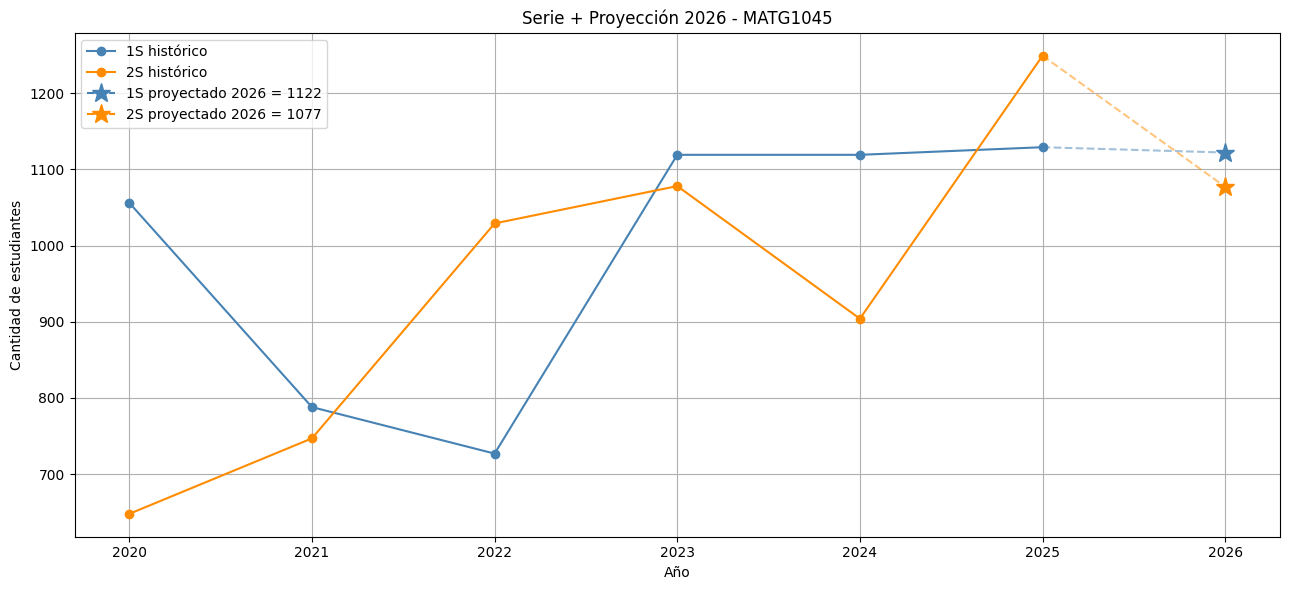


Proyección para MATG1045:
  2026_1S: 1122
  2026_2S: 1077


In [28]:
# --- Visualización para la materia seleccionada ---
codigo_materia = "MATG1045"
# proyecciones = proyectar_materia(df_materia_periodo_nom_mo_cp, codigo_materia)
proyecciones = proyectar_materia_pro(df_materia_periodo_nom_mo_cp, codigo_materia, metodo="media_movil")


graph_serie(codigo_materia, proyecciones)

print(f"\nProyección para {codigo_materia}:")
print(f"  2026_1S: {proyecciones.get('2026_1S', 'N/A')}")
print(f"  2026_2S: {proyecciones.get('2026_2S', 'N/A')}")


In [ ]:
# Proyección para todas las materias
registros = []

for _, row_mat in df_materia_periodo_nom_mo_cp.iterrows():
    cod = row_mat["COD_MATERIA_ACAD_MO"]
    nombre = row_mat["NombreMateria"]
    # proy = proyectar_materia(df_materia_periodo_nom_mo_cp, cod, anios_proyectar=[2026])
    proy = proyectar_materia_pro(df_materia_periodo_nom_mo_cp, cod, anios_proyectar=[2026])
    
    registros.append({
        "COD_MATERIA_ACAD_MO": cod,
        "NombreMateria": nombre,
        "2026_1S_proyectado": proy.get("2026_1S", np.nan),
        "2026_2S_proyectado": proy.get("2026_2S", np.nan),
    })

df_proyecciones = pd.DataFrame(registros)

# añadir último valor real disponible para comparación
last_1S_col = sorted([c for c in df_materia_periodo_nom_mo_cp.columns if isinstance(c, str) and c.endswith("1S")],
                      key=lambda x: int(x.split("_")[0]))[-1]
last_2S_col = sorted([c for c in df_materia_periodo_nom_mo_cp.columns if isinstance(c, str) and c.endswith("2S")],
                      key=lambda x: int(x.split("_")[0]))[-1]

df_proyecciones[f"ultimo_1S ({last_1S_col})"] = df_materia_periodo_nom_mo_cp[last_1S_col].values
df_proyecciones[f"ultimo_2S ({last_2S_col})"] = df_materia_periodo_nom_mo_cp[last_2S_col].values

df_proyecciones = df_proyecciones.sort_values("2026_1S_proyectado", ascending=False).reset_index(drop=True)
df_proyecciones


,COD_MATERIA_ACAD_MO,NombreMateria,2026_1S_proyectado,2026_2S_proyectado,ultimo_1S (2025_1S),ultimo_2S (2025_2S)
0,CCPG1043,FUNDAMENTOS DE PROGRAMACIÓN,1215.0,1063.0,1191,1078
1,MATG1045,CÁLCULO DE UNA VARIABLE,1165.0,1295.0,1129,1249
2,INDG1033,ANÁLISIS Y RESOLUCIÓN DE PROBLEMAS,1065.0,1215.0,1117,1159
3,ADSG1026,CIENCIAS DE LA SOSTENIBILIDAD,668.0,730.0,567,679
4,MATG1046,CÁLCULO VECTORIAL,634.0,818.0,606,844
...,...,...,...,...,...,...
676,OCEG1032,CONTAMINACIÓN MARINA,NaN,0.0,0,3
677,OCEG1037,GESTIÓN DE DRAGADOS,NaN,0.0,0,7
678,OCEG1044,TÉCNICAS DE MANEJO COSTERO,NaN,8.0,0,8
679,OCEG1048,OCEANOGRAFÍA COSTERA,NaN,0.0,0,2


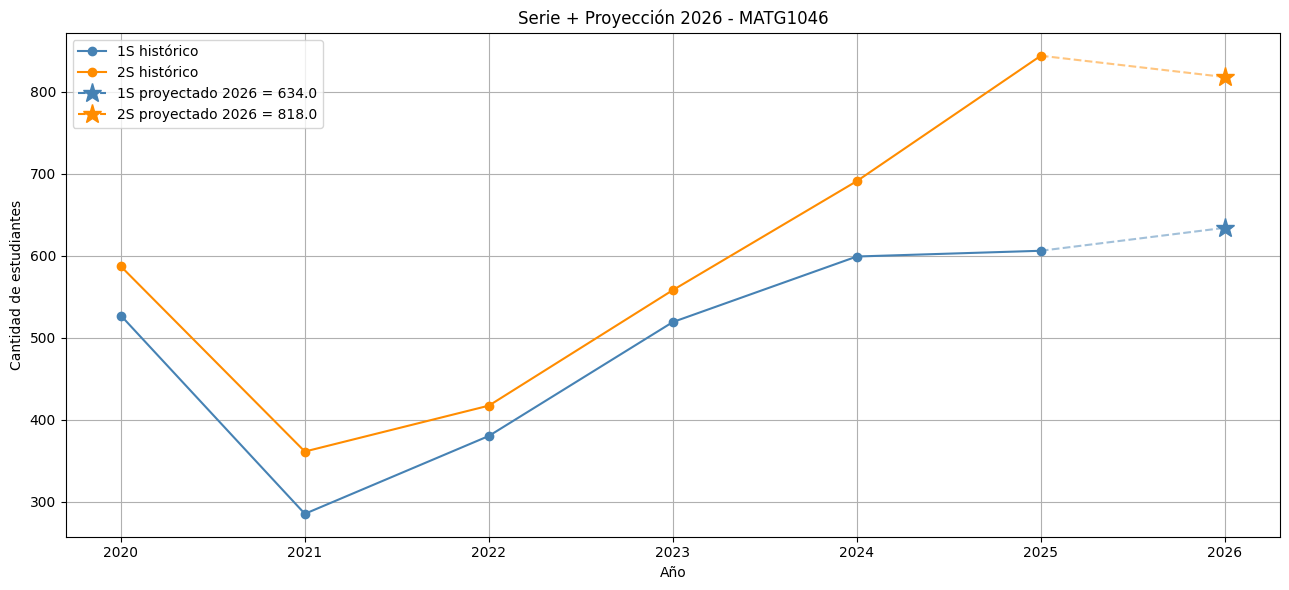

In [37]:
codigo_materia = "MATG1046" #"MATG1045"# "CCPG1043"
df_proyecciones_tmp = df_proyecciones[df_proyecciones["COD_MATERIA_ACAD_MO"] == codigo_materia]
dict_proyectado = {'2026_1S': df_proyecciones_tmp["2026_1S_proyectado"].iloc[0], '2026_2S': df_proyecciones_tmp["2026_2S_proyectado"].iloc[0]}
graph_serie(codigo_materia, dict_proyectado)

In [28]:
df_proyecciones

,COD_MATERIA_ACAD_MO,NombreMateria,2026_1S_proyectado,2026_2S_proyectado,ultimo_1S (2025_1S),ultimo_2S (2025_2S)
0,CCPG1043,FUNDAMENTOS DE PROGRAMACIÓN,1215.0,1063.0,1191,1078
1,MATG1045,CÁLCULO DE UNA VARIABLE,1165.0,1295.0,1129,1249
2,INDG1033,ANÁLISIS Y RESOLUCIÓN DE PROBLEMAS,1065.0,1215.0,1117,1159
3,ADSG1026,CIENCIAS DE LA SOSTENIBILIDAD,668.0,730.0,567,679
4,MATG1046,CÁLCULO VECTORIAL,634.0,818.0,606,844
...,...,...,...,...,...,...
676,OCEG1032,CONTAMINACIÓN MARINA,NaN,0.0,0,3
677,OCEG1037,GESTIÓN DE DRAGADOS,NaN,0.0,0,7
678,OCEG1044,TÉCNICAS DE MANEJO COSTERO,NaN,8.0,0,8
679,OCEG1048,OCEANOGRAFÍA COSTERA,NaN,0.0,0,2


### 2026 1S con el modelo

In [29]:
df_2026_1S_disponibles = df_2026_1S.groupby(["COD_MATERIA_ACAD_MO"]).size().reset_index(name="cantidad_estudiantes")
df_2026_1S_disponibles

,COD_MATERIA_ACAD_MO,cantidad_estudiantes
0,ACUG1035,12
1,ACUG1036,8
2,ACUG1039,9
3,ACUG1040,35
4,ACUG1041,25
...,...,...
635,TURG2033,49
636,TURG2034,59
637,TURG2035,106
638,TURG2036,135


In [51]:
df_estudiantes_novatos

,COD_MATERIA_ACAD,estudiantes_novatos
0,ARQG2041,31
1,ARQG2042,31
2,ARTG2024,38
3,ARTG2025,67
4,CCAG2022,32
5,ECOG2067,50
6,FISG1005,136
7,FISG2002,31
8,GEOG1033,1
9,GEOG1041,1


In [40]:
# sumar los valores de la columna estudiantes_novatos de df_estudiantes_novatos de acuerdo con el COD_MATERIA_ACAD y de df_2026_1S_disponibles con la columna COD_MATERIA_ACAD sumarlo a su cantidad_estudiantes 
df_2026_1S_disponibles_recalc = df_2026_1S_disponibles.merge(
    df_estudiantes_novatos,
    left_on="COD_MATERIA_ACAD_MO",
    right_on="COD_MATERIA_ACAD",
    how="left"
)

# a cero los nulos
df_2026_1S_disponibles_recalc["estudiantes_novatos"] = df_2026_1S_disponibles_recalc["estudiantes_novatos"].fillna(0)
# suma de cantidad de estudiantes y novatos
df_2026_1S_disponibles_recalc["cantidad_estudiantes"] = (
    df_2026_1S_disponibles_recalc["cantidad_estudiantes"] + df_2026_1S_disponibles_recalc["estudiantes_novatos"]
)

# limpiar columna duplicada de merge
df_2026_1S_disponibles_recalc = df_2026_1S_disponibles_recalc.drop(columns=["COD_MATERIA_ACAD"])
df_2026_1S_disponibles_recalc = df_2026_1S_disponibles_recalc.drop(columns=["estudiantes_novatos"])

df_2026_1S_disponibles_recalc

,COD_MATERIA_ACAD_MO,cantidad_estudiantes
0,ACUG1035,12.0
1,ACUG1036,8.0
2,ACUG1039,9.0
3,ACUG1040,35.0
4,ACUG1041,25.0
...,...,...
635,TURG2033,49.0
636,TURG2034,59.0
637,TURG2035,106.0
638,TURG2036,135.0


In [48]:
# agregar disponibles en df_proyecciones a partir de cantidad_estudiantes y estudiantes_novatos de df_2026_1S_disponibles_recalc
df_result = df_proyecciones.merge(df_2026_1S_disponibles_recalc, on="COD_MATERIA_ACAD_MO")
df_result.rename(columns={"cantidad_estudiantes": "disponibles_2026_1S", "2026_1S_proyectado": "2026_1S", "2026_2S_proyectado": "2026_2S", "ultimo_1S (2025_1S)": "2025_1S", "ultimo_2S (2025_2S)": "2025_2S", "COD_MATERIA_ACAD_MO": "CodigoMateria"}, inplace=True)

In [49]:
df_result

,CodigoMateria,NombreMateria,2026_1S,2026_2S,2025_1S,2025_2S,disponibles_2026_1S
0,CCPG1043,FUNDAMENTOS DE PROGRAMACIÓN,1215.0,1063.0,1191,1078,2634.0
1,MATG1045,CÁLCULO DE UNA VARIABLE,1165.0,1295.0,1129,1249,2910.0
2,INDG1033,ANÁLISIS Y RESOLUCIÓN DE PROBLEMAS,1065.0,1215.0,1117,1159,561.0
3,ADSG1026,CIENCIAS DE LA SOSTENIBILIDAD,668.0,730.0,567,679,8935.0
4,MATG1046,CÁLCULO VECTORIAL,634.0,818.0,606,844,1327.0
...,...,...,...,...,...,...,...
635,OCEG1031,CONSTRUCCIÓN DE OBRAS PORTUARIAS,NaN,0.0,0,8,2.0
636,OCEG1032,CONTAMINACIÓN MARINA,NaN,0.0,0,3,6.0
637,OCEG1037,GESTIÓN DE DRAGADOS,NaN,0.0,0,7,8.0
638,OCEG1044,TÉCNICAS DE MANEJO COSTERO,NaN,8.0,0,8,47.0


In [50]:
df_result.to_excel("../data/riesgo_academico/saved/resultado_analisis.xlsx", index=False)